In [1]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "optuna>=4,<5" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "cloudpickle>=3,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import math
import cloudpickle
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
WANDB_GROUP = "nbeats-final-optuna-tuning"

DATA_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/walmart_competition_data"),
    Path("/content/drive/My Drive/walmart_competition_data"),
    Path("/content/walmart_competition_data"),
    Path("../../data"),
    Path("data"),
]

OUTPUT_DIR = (
    Path("/content/artifacts/nbeats_final_optuna")
    if Path("/content").exists()
    else Path("artifacts/nbeats_final_optuna")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "validation_weeks": 32,
    "context_length": 52,
    "forecast_horizon": 32,
    "min_series_length": 84,
    "max_epochs": 18,
    "early_stopping_patience": 4,
    "num_blocks": 4,
    "num_layers": 4,
    "holiday_weight": 5.0,
    "clip_grad_norm": 1.0,
    "num_workers": 0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

OPTUNA_N_TRIALS = 10
OPTUNA_TIMEOUT = None

OPTUNA_SEARCH_SPACE = {
    "optimizer": ["adamw"],
    "loss_type": ["regular_l1"],
    "batch_size": [128, 256],
    "learning_rate": (5e-4, 1.5e-3),
    "hidden_units": [128, 192, 256],
    "num_blocks": [2, 3, 4],
    "num_layers": [2, 3, 4],
    "dropout": (0.05, 0.15),
    "weight_decay": (1e-5, 2e-4),
}

BASELINE_REFERENCE_WMAE = 2157.9829
EXPERIMENT_1_WMAE = 2186.5015
EXPERIMENT_2_WMAE = 2662.8061
EXPERIMENT_3_WMAE = 2185.1366


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
print(f"Using device: {CONFIG['device']}")
print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")

Using device: cuda
Python: 3.12.13
Torch: 2.11.0+cu128


## 2. Load data

In [4]:
def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and (candidate / "train.csv").exists():
            return candidate
    searched = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find train.csv. Searched:\n{searched}")


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
print(f"Data directory: {DATA_DIR}")

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train_cols = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
missing_cols = required_train_cols.difference(train_raw.columns)
if missing_cols:
    raise ValueError(f"train.csv is missing required columns: {sorted(missing_cols)}")

print("train shape:", train_raw.shape)
print("test shape:", test_raw.shape)
print("features shape:", features_raw.shape)
print("stores shape:", stores_raw.shape)
print(
    "date range:", train_raw["Date"].min().date(), "to", train_raw["Date"].max().date()
)

Data directory: /content/drive/MyDrive/walmart_competition_data
train shape: (421570, 5)
test shape: (115064, 4)
features shape: (8190, 12)
stores shape: (45, 3)
date range: 2010-02-05 to 2012-10-26


In [5]:
train_df = train_raw.copy()
train_df["Store"] = train_df["Store"].astype(int)
train_df["Dept"] = train_df["Dept"].astype(int)
train_df = train_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

all_dates = pd.date_range(train_df["Date"].min(), train_df["Date"].max(), freq="W-FRI")
sales_pivot = (
    train_df.pivot_table(
        index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum"
    )
    .reindex(columns=all_dates)
    .sort_index()
)

holiday_by_date = (
    train_df.groupby("Date")["IsHoliday"]
    .max()
    .reindex(all_dates)
    .fillna(False)
    .astype(bool)
)

context_length = CONFIG["context_length"]
forecast_horizon = CONFIG["forecast_horizon"]
validation_weeks = CONFIG["validation_weeks"]
min_required_weeks = context_length + forecast_horizon

valid_series_mask = sales_pivot.notna().sum(axis=1) >= min_required_weeks
sales_pivot = sales_pivot.loc[valid_series_mask]
filled_sales = sales_pivot.ffill(axis=1).bfill(axis=1).fillna(0.0)

series_index = filled_sales.index
series_keys = pd.DataFrame(series_index.tolist(), columns=["Store", "Dept"])

if validation_weeks != forecast_horizon:
    raise ValueError(
        "This notebook expects validation_weeks to equal forecast_horizon."
    )

validation_start = len(all_dates) - validation_weeks
if validation_start < context_length:
    raise ValueError(
        "Not enough historical weeks before validation. Reduce context_length or validation_weeks."
    )

train_dates = all_dates[:validation_start]
validation_dates = all_dates[validation_start:]

sales_values_original = filled_sales.to_numpy(dtype=np.float32)
log_sales_values = np.log1p(
    np.clip(sales_values_original, a_min=0.0, a_max=None)
).astype(np.float32)

series_center = log_sales_values[:, :validation_start].mean(axis=1, keepdims=True)
series_scale = log_sales_values[:, :validation_start].std(axis=1, keepdims=True)
series_scale = np.where(series_scale < 1e-6, 1.0, series_scale).astype(np.float32)
normalized_values = ((log_sales_values - series_center) / series_scale).astype(
    np.float32
)

print("weekly dates:", len(all_dates))
print("usable Store-Dept series:", len(series_index))
print("training date range:", train_dates.min().date(), "to", train_dates.max().date())
print(
    "validation date range:",
    validation_dates.min().date(),
    "to",
    validation_dates.max().date(),
)
print("sales tensor shape:", normalized_values.shape)

weekly dates: 143
usable Store-Dept series: 2921
training date range: 2010-02-05 to 2012-03-16
validation date range: 2012-03-23 to 2012-10-26
sales tensor shape: (2921, 143)


In [6]:
def make_training_windows(
    values: np.ndarray,
    horizon_weights: np.ndarray,
    context: int,
    horizon: int,
    validation_start_idx: int,
):
    X_windows = []
    y_windows = []
    weight_windows = []
    last_window_start = validation_start_idx - context - horizon
    if last_window_start < 0:
        raise ValueError(
            "Not enough history to create training windows before validation."
        )

    for series_id in range(values.shape[0]):
        for start in range(last_window_start + 1):
            split = start + context
            target_slice = slice(split, split + horizon)
            X_windows.append(values[series_id, start:split])
            y_windows.append(values[series_id, target_slice])
            weight_windows.append(horizon_weights[target_slice])

    return (
        np.asarray(X_windows, dtype=np.float32),
        np.asarray(y_windows, dtype=np.float32),
        np.asarray(weight_windows, dtype=np.float32),
    )


all_horizon_weights = np.where(
    holiday_by_date.to_numpy(dtype=bool),
    CONFIG["holiday_weight"],
    1.0,
).astype(np.float32)

X_train, y_train, train_target_weights = make_training_windows(
    normalized_values,
    all_horizon_weights,
    context_length,
    forecast_horizon,
    validation_start,
)

X_val = normalized_values[
    :, validation_start - context_length : validation_start
].astype(np.float32)
y_val_original = sales_values_original[
    :, validation_start : validation_start + forecast_horizon
].astype(np.float32)
val_holiday_flags = holiday_by_date.loc[validation_dates].to_numpy(dtype=bool)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("train_target_weights:", train_target_weights.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val_original.shape)
print("validation holiday weeks:", int(val_holiday_flags.sum()))

X_train: (81788, 52)
y_train: (81788, 32)
train_target_weights: (81788, 32)
X_val: (2921, 52)
y_val: (2921, 32)
validation holiday weeks: 1


## 4. Log preprocessing to W&B

In [7]:
wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)

preprocessing_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_preprocessing",
    name="NBEATS_Final_Optuna_Preprocessing",
    config={
        **CONFIG,
        "seed": SEED,
        "model_family": "N-BEATS",
        "experiment_type": "final_optuna_hyperparameter_tuning",
        "data_dir": str(DATA_DIR),
        "train_rows": int(len(train_raw)),
        "test_rows": int(len(test_raw)),
        "usable_series": int(len(series_index)),
        "train_windows": int(len(X_train)),
        "total_weeks": int(len(all_dates)),
        "train_start_date": str(train_dates.min().date()),
        "train_end_date": str(train_dates.max().date()),
        "validation_start_date": str(validation_dates.min().date()),
        "validation_end_date": str(validation_dates.max().date()),
        "target_transform": "clip_negative_then_log1p",
        "series_scaling": "per_series_standardization_fit_on_training_period",
        "optuna_n_trials": OPTUNA_N_TRIALS,
        "optuna_timeout": OPTUNA_TIMEOUT,
        "search_space": OPTUNA_SEARCH_SPACE,
    },
)
preprocessing_run.log(
    {
        "final_optuna/usable_series": len(series_index),
        "final_optuna/train_windows": len(X_train),
    }
)
preprocessing_run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nmetr23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


final_optuna/train_windows,▁
final_optuna/usable_series,▁
final_optuna/train_windows,81788
final_optuna/usable_series,2921


## 5. Model, dataset, and metric definitions

In [8]:
class WindowDataset(Dataset):
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray | None = None,
        weights: np.ndarray | None = None,
    ):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.float32))
        self.weights = (
            None if weights is None else torch.from_numpy(weights.astype(np.float32))
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        if self.weights is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.weights[idx]


class NBeatsBlock(nn.Module):
    def __init__(
        self,
        input_size: int,
        horizon: int,
        hidden_units: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        layers = []
        current_size = input_size
        for _ in range(num_layers):
            layers.append(nn.Linear(current_size, hidden_units))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            current_size = hidden_units
        self.net = nn.Sequential(*layers)
        self.backcast_head = nn.Linear(hidden_units, input_size)
        self.forecast_head = nn.Linear(hidden_units, horizon)

    def forward(self, x):
        hidden = self.net(x)
        return self.backcast_head(hidden), self.forecast_head(hidden)


class NBeats(nn.Module):
    def __init__(
        self,
        input_size: int,
        horizon: int,
        hidden_units: int,
        num_blocks: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        self.horizon = horizon
        self.blocks = nn.ModuleList(
            [
                NBeatsBlock(input_size, horizon, hidden_units, num_layers, dropout)
                for _ in range(num_blocks)
            ]
        )

    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.size(0), self.horizon, device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast


def inverse_transform_predictions(
    pred_normalized: np.ndarray, center: np.ndarray, scale: np.ndarray
) -> np.ndarray:
    pred_log = pred_normalized * scale + center
    pred_sales = np.expm1(pred_log)
    return np.clip(pred_sales, a_min=0.0, a_max=None)


def weighted_mae(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    holiday_flags: np.ndarray,
    holiday_weight: float = 5.0,
) -> float:
    weights = np.where(holiday_flags.reshape(1, -1), holiday_weight, 1.0)
    weights = np.broadcast_to(weights, y_true.shape)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def regular_l1_loss(
    prediction: torch.Tensor, target: torch.Tensor, weights: torch.Tensor
) -> torch.Tensor:
    return torch.mean(torch.abs(prediction - target))


def holiday_weighted_l1_loss(
    prediction: torch.Tensor, target: torch.Tensor, weights: torch.Tensor
) -> torch.Tensor:
    return (torch.abs(prediction - target) * weights).sum() / weights.sum()

## 6. Seasonal naive reference

In [9]:
seasonal_naive_pred = sales_values_original[
    :, validation_start - forecast_horizon : validation_start
]
baseline_wmae = weighted_mae(
    y_val_original, seasonal_naive_pred, val_holiday_flags, CONFIG["holiday_weight"]
)
baseline_mae = mae(y_val_original, seasonal_naive_pred)
baseline_rmse = rmse(y_val_original, seasonal_naive_pred)

print(f"Seasonal naive validation WMAE: {baseline_wmae:.4f}")
print(f"Seasonal naive validation MAE: {baseline_mae:.4f}")
print(f"Seasonal naive validation RMSE: {baseline_rmse:.4f}")

Seasonal naive validation WMAE: 3902.8521
Seasonal naive validation MAE: 3946.3479
Seasonal naive validation RMSE: 10482.2129


## 7. Final Optuna hyperparameter tuning

This fast rerun uses 10 focused Optuna trials around the strong baseline region. Trial 0 explicitly reproduces the baseline configuration. The search uses AdamW and regular L1 (the recorded holiday-weighted experiment was worse), tests 2–4 blocks, 2–4 layers, 128–256 hidden units, batch sizes 128/256, and a narrow learning-rate range. Trials run for at most 18 epochs with early stopping patience 4, pruning, gradient clipping, and ReduceLROnPlateau. DataLoader workers and expensive W&B gradient watching are disabled for Colab stability.


In [10]:
def evaluate_model(model: nn.Module, X: np.ndarray, batch_size: int = 512):
    model.eval()
    predictions = []
    loader = DataLoader(
        WindowDataset(X), batch_size=batch_size, shuffle=False, num_workers=0
    )
    with torch.no_grad():
        for batch_X in loader:
            batch_X = batch_X.to(CONFIG["device"])
            predictions.append(model(batch_X).cpu().numpy())
    return np.concatenate(predictions, axis=0)


def suggest_params(trial: optuna.Trial) -> dict:
    return {
        "optimizer": trial.suggest_categorical(
            "optimizer", OPTUNA_SEARCH_SPACE["optimizer"]
        ),
        "loss_type": trial.suggest_categorical(
            "loss_type", OPTUNA_SEARCH_SPACE["loss_type"]
        ),
        "batch_size": trial.suggest_categorical(
            "batch_size", OPTUNA_SEARCH_SPACE["batch_size"]
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", *OPTUNA_SEARCH_SPACE["learning_rate"], log=True
        ),
        "hidden_units": trial.suggest_categorical(
            "hidden_units", OPTUNA_SEARCH_SPACE["hidden_units"]
        ),
        "num_blocks": trial.suggest_categorical(
            "num_blocks", OPTUNA_SEARCH_SPACE["num_blocks"]
        ),
        "num_layers": trial.suggest_categorical(
            "num_layers", OPTUNA_SEARCH_SPACE["num_layers"]
        ),
        "dropout": trial.suggest_float("dropout", *OPTUNA_SEARCH_SPACE["dropout"]),
        "weight_decay": trial.suggest_float(
            "weight_decay", *OPTUNA_SEARCH_SPACE["weight_decay"], log=True
        ),
    }


def train_one_trial(
    trial_id: int,
    total_trials: int,
    trial_params: dict,
    optuna_trial: optuna.Trial | None = None,
):
    seed_everything(SEED + trial_id)
    trial_config = {**CONFIG, **trial_params}

    print(
        f"\nStarting trial {trial_id + 1}/{total_trials}: "
        f"blocks={trial_params.get('num_blocks', CONFIG['num_blocks'])}, "
        f"layers={trial_params.get('num_layers', CONFIG['num_layers'])}, "
        f"hidden={trial_config['hidden_units']}, batch={trial_config['batch_size']}, "
        f"lr={trial_config['learning_rate']:.6f}"
    )

    train_loader = DataLoader(
        WindowDataset(X_train, y_train, train_target_weights),
        batch_size=trial_config["batch_size"],
        shuffle=True,
        num_workers=trial_config["num_workers"],
        pin_memory=trial_config["device"] == "cuda",
    )

    model = NBeats(
        input_size=context_length,
        horizon=forecast_horizon,
        hidden_units=trial_config["hidden_units"],
        num_blocks=trial_params.get("num_blocks", trial_config["num_blocks"]),
        num_layers=trial_params.get("num_layers", trial_config["num_layers"]),
        dropout=trial_config["dropout"],
    ).to(trial_config["device"])

    if trial_config["optimizer"] == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
        )
    elif trial_config["optimizer"] == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
        )
    elif trial_config["optimizer"] == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=trial_config["learning_rate"],
            weight_decay=trial_config["weight_decay"],
            momentum=0.9,
        )
    else:
        raise ValueError(f"Unsupported optimizer: {trial_config['optimizer']}")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
    )
    loss_fn = (
        holiday_weighted_l1_loss
        if trial_config["loss_type"] == "holiday_weighted_l1"
        else regular_l1_loss
    )

    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        group=WANDB_GROUP,
        job_type="final_optuna_trial",
        name=f"NBEATS_Final_Optuna_Trial_{trial_id:03d}",
        config={
            **trial_config,
            "seed": SEED + trial_id,
            "trial_id": trial_id,
            "total_trials": total_trials,
            "model_family": "N-BEATS",
            "experiment_type": "final_optuna_hyperparameter_tuning",
            "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
            "experiment_1_reference_weighted_mae": EXPERIMENT_1_WMAE,
            "experiment_2_reference_weighted_mae": EXPERIMENT_2_WMAE,
            "experiment_3_reference_weighted_mae": EXPERIMENT_3_WMAE,
            "train_windows": int(len(X_train)),
            "validation_series": int(len(X_val)),
        },
    )
    # Gradient watching is intentionally disabled: it adds substantial overhead
    # across Optuna trials while run.log below still records all useful metrics.

    best_wmae = math.inf
    best_epoch = -1
    best_val_pred = None
    best_state_dict = None
    epochs_without_improvement = 0
    early_stopped = False

    for epoch in range(1, trial_config["max_epochs"] + 1):
        model.train()
        train_losses = []

        for batch_X, batch_y, batch_weights in train_loader:
            batch_X = batch_X.to(trial_config["device"])
            batch_y = batch_y.to(trial_config["device"])
            batch_weights = batch_weights.to(trial_config["device"])

            optimizer.zero_grad(set_to_none=True)
            batch_pred = model(batch_X)
            loss = loss_fn(batch_pred, batch_y, batch_weights)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), trial_config["clip_grad_norm"])
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_pred_normalized = evaluate_model(model, X_val)
        val_pred_original = inverse_transform_predictions(
            val_pred_normalized, series_center, series_scale
        )

        validation_wmae = weighted_mae(
            y_val_original,
            val_pred_original,
            val_holiday_flags,
            trial_config["holiday_weight"],
        )
        validation_mae = mae(y_val_original, val_pred_original)
        validation_rmse = rmse(y_val_original, val_pred_original)
        scheduler.step(validation_wmae)

        run.log(
            {
                "epoch": epoch,
                "train/loss": train_loss,
                "validation/weighted_mae": validation_wmae,
                "validation/mae": validation_mae,
                "validation/rmse": validation_rmse,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        if optuna_trial is not None:
            optuna_trial.report(validation_wmae, step=epoch)
            if optuna_trial.should_prune():
                run.summary["pruned"] = True
                run.finish()
                raise optuna.TrialPruned()

        if validation_wmae < best_wmae:
            best_wmae = validation_wmae
            best_epoch = epoch
            best_val_pred = val_pred_original.copy()
            best_state_dict = {
                key: value.detach().cpu() for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Trial {trial_id + 1:03d}/{total_trials:03d} | epoch {epoch:03d}/{trial_config['max_epochs']:03d} | "
            f"optimizer={trial_config['optimizer']} loss={trial_config['loss_type']} lr={trial_config['learning_rate']:.6f} batch={trial_config['batch_size']} | "
            f"train={train_loss:.5f} val WMAE={validation_wmae:.4f} | "
            f"no improvement={epochs_without_improvement}/{trial_config['early_stopping_patience']}"
        )

        if epochs_without_improvement >= trial_config["early_stopping_patience"]:
            early_stopped = True
            print(
                f"Early stopping trial {trial_id} at epoch {epoch}. Best epoch was {best_epoch}."
            )
            break

    run.summary["best_epoch"] = best_epoch
    run.summary["best_validation_weighted_mae"] = best_wmae
    run.summary["early_stopped"] = early_stopped
    run.finish()

    return {
        "trial_id": trial_id,
        "best_epoch": best_epoch,
        "best_validation_weighted_mae": best_wmae,
        "early_stopped": early_stopped,
        "val_predictions": best_val_pred,
        "state_dict": best_state_dict,
        **trial_params,
    }


optuna_results = []
best_trial_result = None

sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=4, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

# Trial 0 reproduces the strong baseline. Optuna therefore searches from a
# known 2,157.98-WMAE region instead of hoping to sample it by chance.
study.enqueue_trial(
    {
        "optimizer": "adamw",
        "loss_type": "regular_l1",
        "batch_size": 128,
        "learning_rate": 1e-3,
        "hidden_units": 256,
        "num_blocks": 4,
        "num_layers": 4,
        "dropout": 0.10,
        "weight_decay": 1e-4,
    }
)


def objective(trial: optuna.Trial) -> float:
    global best_trial_result
    params = suggest_params(trial)
    result = train_one_trial(trial.number, OPTUNA_N_TRIALS, params, optuna_trial=trial)
    result_for_table = {
        key: value
        for key, value in result.items()
        if key not in {"val_predictions", "state_dict"}
    }
    optuna_results.append(result_for_table)

    if (
        best_trial_result is None
        or result["best_validation_weighted_mae"]
        < best_trial_result["best_validation_weighted_mae"]
    ):
        best_trial_result = result

    return result["best_validation_weighted_mae"]


study.optimize(
    objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=True
)

if best_trial_result is None:
    raise RuntimeError("Optuna did not complete any successful trials.")

optuna_results_df = (
    pd.DataFrame(optuna_results)
    .sort_values("best_validation_weighted_mae")
    .reset_index(drop=True)
)
optuna_results_path = OUTPUT_DIR / "nbeats_final_optuna_results.csv"
optuna_results_df.to_csv(optuna_results_path, index=False)

summary_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_summary",
    name="NBEATS_Final_Optuna_Tuning_Summary",
    config={
        **CONFIG,
        "optuna_n_trials": OPTUNA_N_TRIALS,
        "optuna_timeout": OPTUNA_TIMEOUT,
        "search_space": OPTUNA_SEARCH_SPACE,
        "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
        "experiment_1_reference_weighted_mae": EXPERIMENT_1_WMAE,
        "experiment_2_reference_weighted_mae": EXPERIMENT_2_WMAE,
        "experiment_3_reference_weighted_mae": EXPERIMENT_3_WMAE,
    },
)
summary_run.log(
    {
        "final_optuna/results": wandb.Table(dataframe=optuna_results_df),
        "final_optuna/best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
        "final_optuna/best_trial_id": best_trial_result["trial_id"],
    }
)
summary_run.summary["best_trial_id"] = best_trial_result["trial_id"]
summary_run.summary["best_epoch"] = best_trial_result["best_epoch"]
summary_run.summary["best_validation_weighted_mae"] = best_trial_result[
    "best_validation_weighted_mae"
]
summary_run.summary["best_params"] = study.best_params
summary_run.finish()

print("--- Final Optuna top 10 ---")
print(optuna_results_df.head(10))
print("Best Optuna params:")
print(study.best_params)
print("Best trial result:")
print(best_trial_result)

/tmp/ipykernel_724/1284186987.py:235: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=4, multivariate=True)
[I 2026-07-17 15:04:12,252] A new study created in memory with name: no-name-e8ca4282-94fd-477e-ab0b-286e725c87f7


  0%|          | 0/10 [00:00<?, ?it/s]


Starting trial 1/10: blocks=4, layers=4, hidden=256, batch=128, lr=0.001000


Trial 001/010 | epoch 001/018 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.52566 val WMAE=2211.7457 | no improvement=0/4
Trial 001/010 | epoch 002/018 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.48914 val WMAE=2259.1715 | no improvement=1/4
Trial 001/010 | epoch 003/018 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.47685 val WMAE=2229.5276 | no improvement=2/4
Trial 001/010 | epoch 004/018 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.46870 val WMAE=2229.5486 | no improvement=3/4
Trial 001/010 | epoch 005/018 | optimizer=adamw loss=regular_l1 lr=0.001000 batch=128 | train=0.45551 val WMAE=2231.1204 | no improvement=4/4
Early stopping trial 0 at epoch 5. Best epoch was 1.


epoch,▁▃▅▆█
learning_rate,███▁▁
train/loss,█▄▃▂▁
validation/mae,▁█▃▄▄
validation/rmse,▁█▃▄▄
validation/weighted_mae,▁█▄▄▄
best_epoch,1
best_validation_weighted_mae,2211.74572
early_stopped,True
epoch,5
learning_rate,0.0005


...

Trial 010/010 | epoch 001/018 | optimizer=adamw loss=regular_l1 lr=0.001206 batch=256 | train=0.52529 val WMAE=2220.9850 | no improvement=0/4


epoch,▁█
learning_rate,▁▁
train/loss,█▁
validation/mae,▁█
validation/rmse,▁█
validation/weighted_mae,▁█
epoch,2
learning_rate,0.00121
pruned,True
train/loss,0.48918
validation/mae,2213.229


[I 2026-07-17 15:08:21,700] Trial 9 pruned. 


final_optuna/best_trial_id,▁
final_optuna/best_validation_weighted_mae,▁
best_epoch,3
best_trial_id,3
best_validation_weighted_mae,2122.15222
final_optuna/best_trial_id,3
final_optuna/best_validation_weighted_mae,2122.15222


--- Final Optuna top 10 ---
   trial_id  best_epoch  best_validation_weighted_mae  early_stopped  \
0         3           3                   2122.152222           True   
1         8           3                   2146.498442           True   
2         6           3                   2154.897935           True   
3         2           4                   2168.842578           True   
4         5           3                   2181.197644           True   
5         4           2                   2183.804308           True   
6         1           8                   2188.476902           True   
7         0           1                   2211.745723           True   

  optimizer   loss_type  batch_size  learning_rate  hidden_units  num_blocks  \
0     adamw  regular_l1         128       0.000975           256           2   
1     adamw  regular_l1         256       0.001327           192           2   
2     adamw  regular_l1         128       0.001390           128           2   
3  

## 8. Best Optuna trial diagnostics

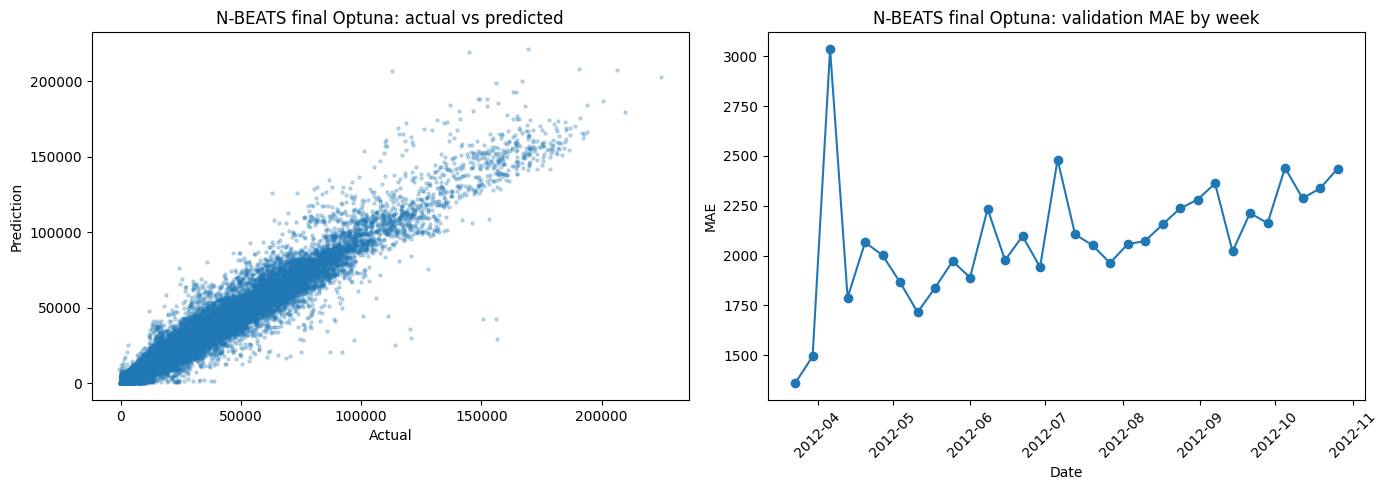

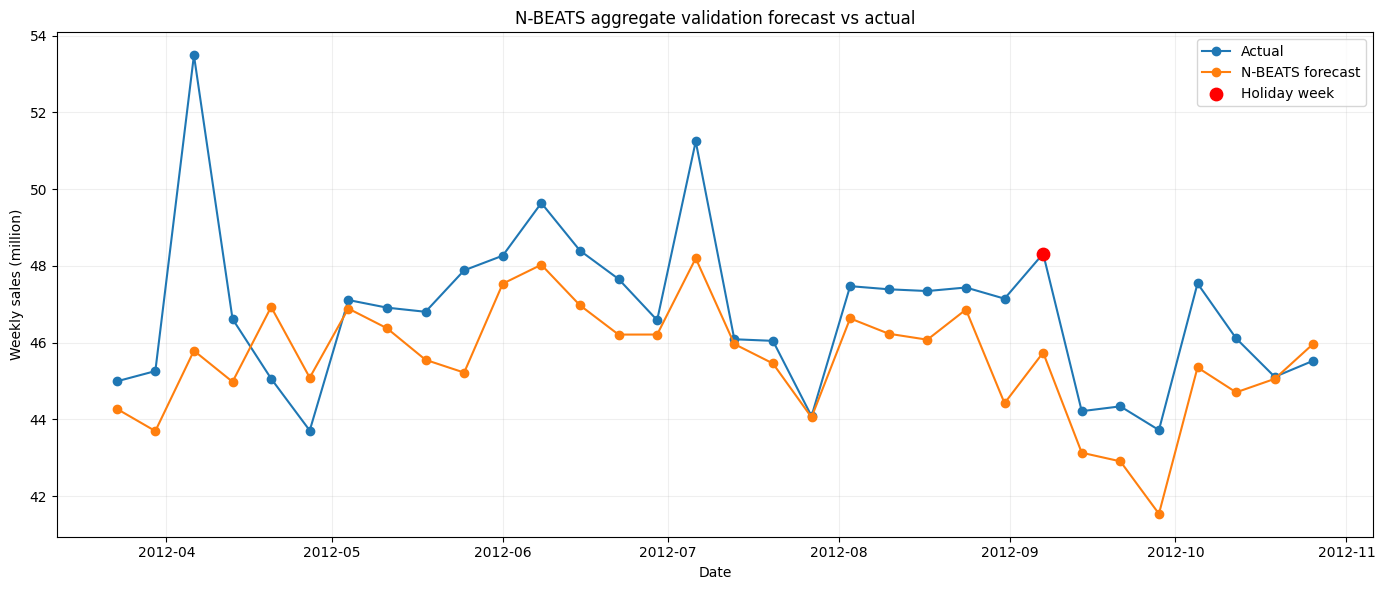

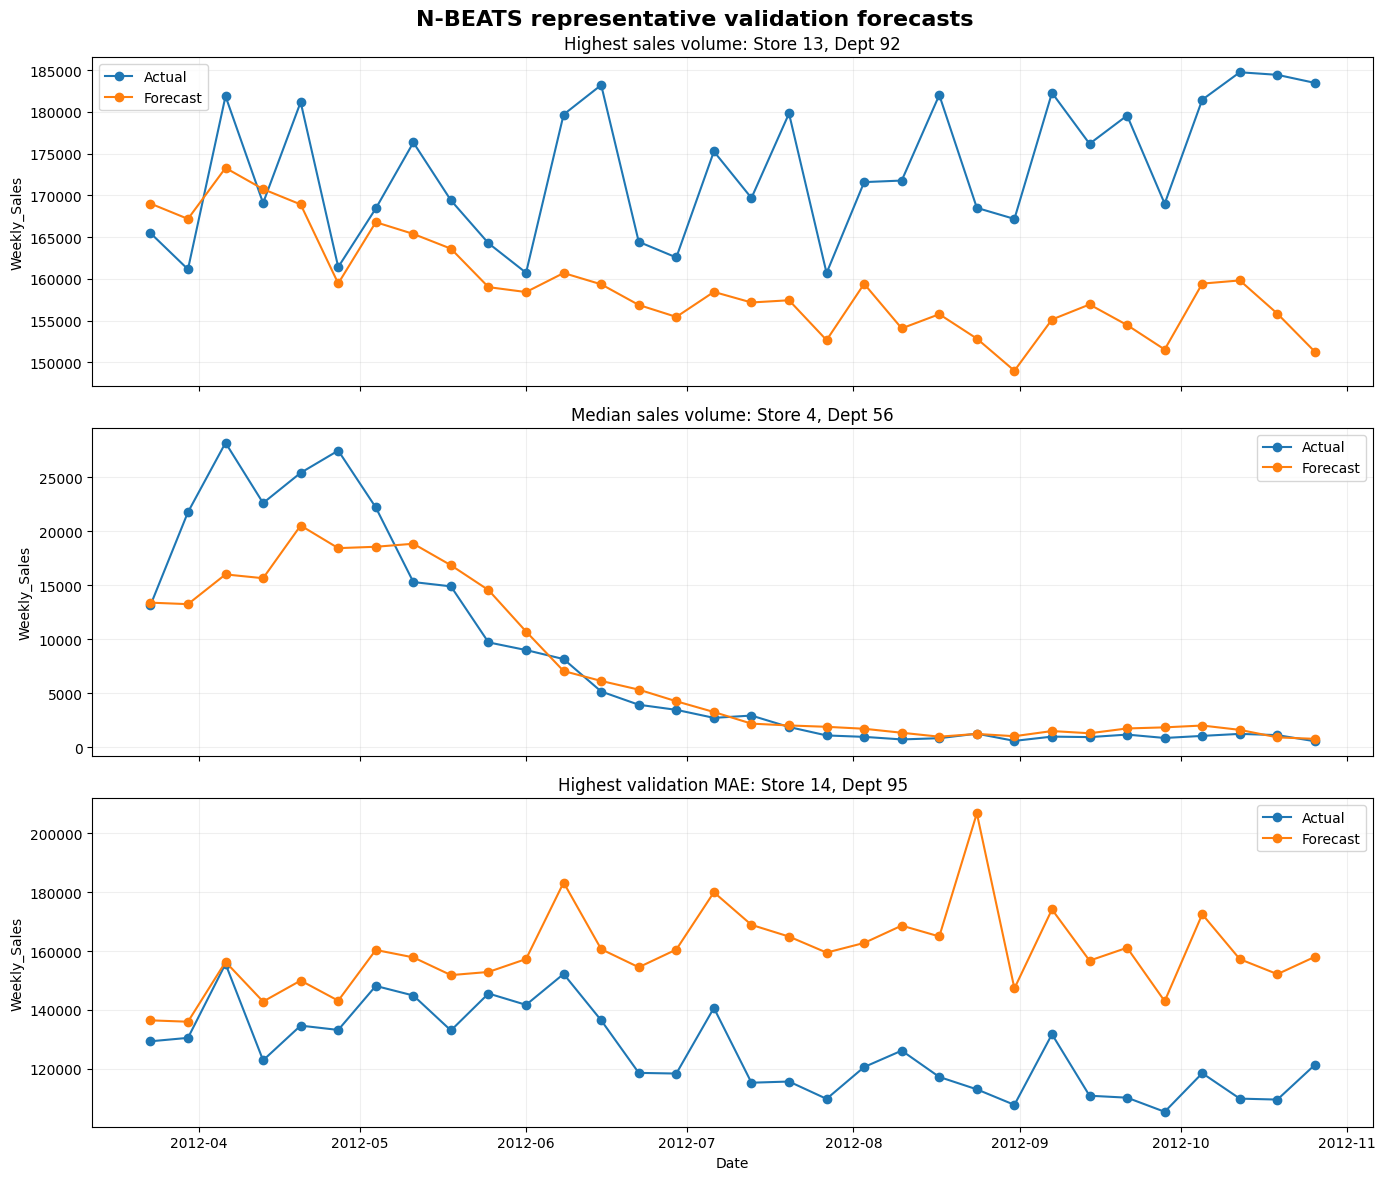

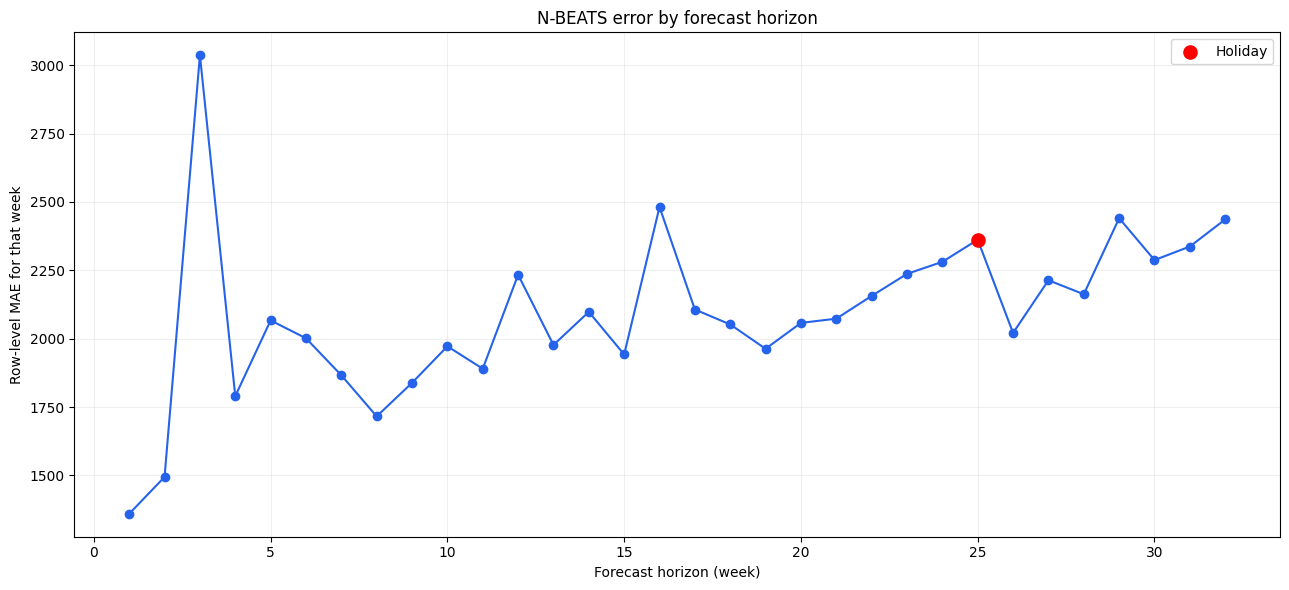

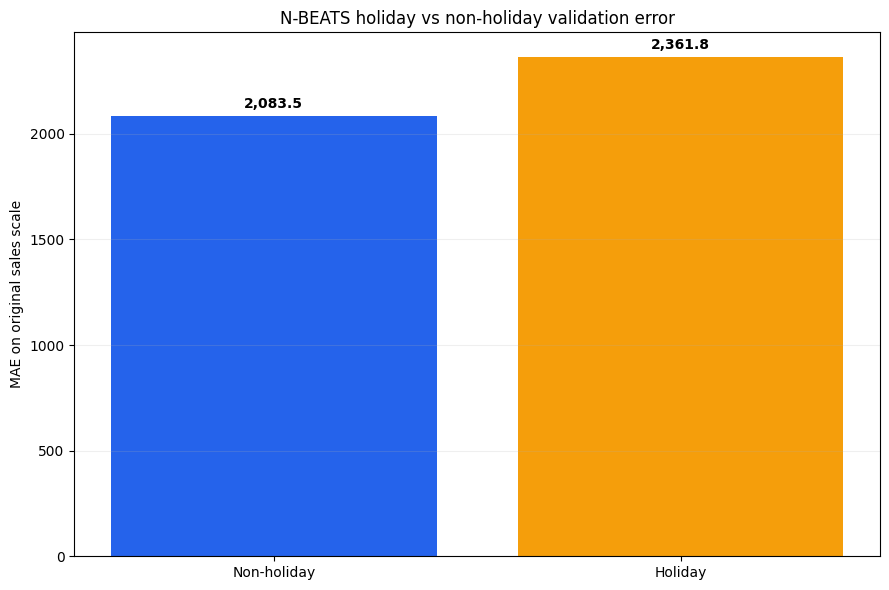

final_optuna/best_validation_weighted_mae,▁
final_optuna/best_validation_weighted_mae,2122.15222


Logged final Optuna tuning results and best-trial diagnostics to W&B.
No model artifact or Model Registry entry was created.


In [11]:
best_val_pred_original = best_trial_result["val_predictions"]

prediction_rows = []
for series_id, (store, dept) in enumerate(series_index):
    for horizon_idx, date in enumerate(validation_dates):
        actual = float(y_val_original[series_id, horizon_idx])
        prediction = float(best_val_pred_original[series_id, horizon_idx])
        prediction_rows.append(
            {
                "Store": int(store),
                "Dept": int(dept),
                "Date": date,
                "Weekly_Sales": actual,
                "Prediction": prediction,
                "IsHoliday": bool(val_holiday_flags[horizon_idx]),
                "AbsoluteError": abs(actual - prediction),
            }
        )

val_predictions_df = pd.DataFrame(prediction_rows)
weekly_errors_df = val_predictions_df.groupby("Date", as_index=False).agg(
    Weekly_MAE=("AbsoluteError", "mean"), IsHoliday=("IsHoliday", "max")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    val_predictions_df["Weekly_Sales"],
    val_predictions_df["Prediction"],
    s=5,
    alpha=0.25,
)
axes[0].set_title("N-BEATS final Optuna: actual vs predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Prediction")

axes[1].plot(weekly_errors_df["Date"], weekly_errors_df["Weekly_MAE"], marker="o")
axes[1].set_title("N-BEATS final Optuna: validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 1) Aggregate weekly forecast versus actual.
aggregate_weekly_df = (
    val_predictions_df.groupby("Date", as_index=False)
    .agg(Actual=("Weekly_Sales", "sum"), Forecast=("Prediction", "sum"), IsHoliday=("IsHoliday", "max"))
    .sort_values("Date")
)
fig_aggregate, ax = plt.subplots(figsize=(14, 6))
ax.plot(aggregate_weekly_df["Date"], aggregate_weekly_df["Actual"] / 1e6, marker="o", label="Actual")
ax.plot(aggregate_weekly_df["Date"], aggregate_weekly_df["Forecast"] / 1e6, marker="o", label="N-BEATS forecast")
holiday_rows = aggregate_weekly_df[aggregate_weekly_df["IsHoliday"]]
ax.scatter(holiday_rows["Date"], holiday_rows["Actual"] / 1e6, color="red", s=80, zorder=5, label="Holiday week")
ax.set(title="N-BEATS aggregate validation forecast vs actual", xlabel="Date", ylabel="Weekly sales (million)")
ax.grid(alpha=0.2); ax.legend(); fig_aggregate.tight_layout()

# 2) Representative Store-Dept series: high volume, median volume, and highest MAE.
series_stats = (
    val_predictions_df.groupby(["Store", "Dept"], as_index=False)
    .agg(MeanSales=("Weekly_Sales", "mean"), MAE=("AbsoluteError", "mean"))
)
high_key = tuple(series_stats.loc[series_stats["MeanSales"].idxmax(), ["Store", "Dept"]].astype(int))
median_order = series_stats.sort_values("MeanSales").reset_index(drop=True)
median_key = tuple(median_order.loc[len(median_order) // 2, ["Store", "Dept"]].astype(int))
error_key = tuple(series_stats.loc[series_stats["MAE"].idxmax(), ["Store", "Dept"]].astype(int))
representatives = [("Highest sales volume", high_key), ("Median sales volume", median_key), ("Highest validation MAE", error_key)]
fig_series, axes_series = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for axis, (label, (store, dept)) in zip(axes_series, representatives):
    subset = val_predictions_df[(val_predictions_df["Store"] == store) & (val_predictions_df["Dept"] == dept)].sort_values("Date")
    axis.plot(subset["Date"], subset["Weekly_Sales"], marker="o", label="Actual")
    axis.plot(subset["Date"], subset["Prediction"], marker="o", label="Forecast")
    axis.set_title(f"{label}: Store {store}, Dept {dept}")
    axis.set_ylabel("Weekly_Sales"); axis.grid(alpha=0.2); axis.legend()
axes_series[-1].set_xlabel("Date"); fig_series.suptitle("N-BEATS representative validation forecasts", fontsize=16, fontweight="bold"); fig_series.tight_layout()

# 3) Real block decomposition for the highest-volume validation series.
decomposition_model = NBeats(
    input_size=context_length,
    horizon=forecast_horizon,
    hidden_units=best_trial_result["hidden_units"],
    num_blocks=best_trial_result.get("num_blocks", CONFIG["num_blocks"]),
    num_layers=best_trial_result.get("num_layers", CONFIG["num_layers"]),
    dropout=best_trial_result["dropout"],
).to(CONFIG["device"])
decomposition_model.load_state_dict(best_trial_result["state_dict"])
decomposition_model.eval()
decomposition_series_id = int(series_index.get_loc(high_key))
decomposition_input = torch.from_numpy(X_val[decomposition_series_id:decomposition_series_id + 1]).float().to(CONFIG["device"])
residual = decomposition_input
block_rows = []
forecast_sum = torch.zeros(1, forecast_horizon, device=CONFIG["device"])
with torch.no_grad():
    for block_id, block in enumerate(decomposition_model.blocks, start=1):
        residual_before = residual.clone()
        backcast, block_forecast = block(residual_before)
        residual = residual_before - backcast
        forecast_sum = forecast_sum + block_forecast
        block_rows.append(
            {
                "block": block_id,
                "residual_before": residual_before.cpu().numpy()[0],
                "backcast": backcast.cpu().numpy()[0],
                "residual_after": residual.cpu().numpy()[0],
                "forecast": block_forecast.cpu().numpy()[0],
            }
        )
num_selected_blocks = len(block_rows)
fig_blocks, axes_blocks = plt.subplots(num_selected_blocks, 2, figsize=(15, 4 * num_selected_blocks), squeeze=False)
for row_index, block_data in enumerate(block_rows):
    left_axis, right_axis = axes_blocks[row_index]
    left_axis.plot(range(1, context_length + 1), block_data["residual_before"], label="Residual entering block")
    left_axis.plot(range(1, context_length + 1), block_data["backcast"], label="Learned backcast")
    left_axis.plot(range(1, context_length + 1), block_data["residual_after"], label="Residual after subtraction")
    left_axis.set_title(f"Block {block_data['block']}: backcast and residual (normalized scale)")
    left_axis.set_xlabel("Context week"); left_axis.grid(alpha=0.2); left_axis.legend()
    right_axis.plot(range(1, forecast_horizon + 1), block_data["forecast"], marker="o", label=f"Block {block_data['block']} forecast contribution")
    right_axis.set_title(f"Block {block_data['block']}: 32-week forecast contribution")
    right_axis.set_xlabel("Forecast horizon"); right_axis.grid(alpha=0.2); right_axis.legend()
fig_blocks.suptitle(f"N-BEATS real block decomposition — Store {high_key[0]}, Dept {high_key[1]}", fontsize=16, fontweight="bold")
fig_blocks.tight_layout()

# 4) WMAE by direct forecast horizon (1..32).
horizon_rows = []
for horizon, date in enumerate(sorted(val_predictions_df["Date"].unique()), start=1):
    subset = val_predictions_df[val_predictions_df["Date"] == date]
    weight = 5.0 if bool(subset["IsHoliday"].max()) else 1.0
    horizon_rows.append({"Horizon": horizon, "Date": date, "WMAE": float((weight * subset["AbsoluteError"]).sum() / (weight * len(subset))), "IsHoliday": weight == 5.0})
horizon_errors_df = pd.DataFrame(horizon_rows)
fig_horizon, ax = plt.subplots(figsize=(13, 6))
ax.plot(horizon_errors_df["Horizon"], horizon_errors_df["WMAE"], marker="o", color="#2563EB")
holiday_horizons = horizon_errors_df[horizon_errors_df["IsHoliday"]]
ax.scatter(holiday_horizons["Horizon"], holiday_horizons["WMAE"], color="red", s=90, zorder=5, label="Holiday")
ax.set(title="N-BEATS error by forecast horizon", xlabel="Forecast horizon (week)", ylabel="Row-level MAE for that week")
ax.grid(alpha=0.2); ax.legend(); fig_horizon.tight_layout()

# 5) Holiday versus non-holiday absolute error.
holiday_error_df = val_predictions_df.groupby("IsHoliday", as_index=False).agg(MAE=("AbsoluteError", "mean"), Rows=("AbsoluteError", "size"))
holiday_error_df["Period"] = holiday_error_df["IsHoliday"].map({False: "Non-holiday", True: "Holiday"})
fig_holiday, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(holiday_error_df["Period"], holiday_error_df["MAE"], color=["#2563EB", "#F59E0B"][:len(holiday_error_df)])
for bar, value in zip(bars, holiday_error_df["MAE"]): ax.text(bar.get_x() + bar.get_width()/2, value + 40, f"{value:,.1f}", ha="center", fontweight="bold")
ax.set(title="N-BEATS holiday vs non-holiday validation error", ylabel="MAE on original sales scale"); ax.grid(axis="y", alpha=0.2); fig_holiday.tight_layout()

predictions_path = OUTPUT_DIR / "final_optuna_best_validation_predictions.csv"
weekly_errors_path = OUTPUT_DIR / "final_optuna_best_weekly_validation_errors.csv"
aggregate_plot_path = OUTPUT_DIR / "nbeats_aggregate_actual_vs_forecast.png"
series_plot_path = OUTPUT_DIR / "nbeats_representative_series_actual_vs_forecast.png"
horizon_plot_path = OUTPUT_DIR / "nbeats_wmae_by_forecast_horizon.png"
holiday_plot_path = OUTPUT_DIR / "nbeats_holiday_vs_nonholiday_error.png"
block_plot_path = OUTPUT_DIR / "nbeats_real_backcast_forecast_decomposition.png"

val_predictions_df.to_csv(predictions_path, index=False)
weekly_errors_df.to_csv(weekly_errors_path, index=False)
horizon_errors_df.to_csv(OUTPUT_DIR / "nbeats_horizon_errors.csv", index=False)
holiday_error_df.to_csv(OUTPUT_DIR / "nbeats_holiday_errors.csv", index=False)
fig_aggregate.savefig(aggregate_plot_path, dpi=220, bbox_inches="tight")
fig_series.savefig(series_plot_path, dpi=220, bbox_inches="tight")
fig_horizon.savefig(horizon_plot_path, dpi=220, bbox_inches="tight")
fig_holiday.savefig(holiday_plot_path, dpi=220, bbox_inches="tight")
fig_blocks.savefig(block_plot_path, dpi=220, bbox_inches="tight")
plt.show()

analysis_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="final_optuna_evaluation",
    name="NBEATS_Final_Optuna_Best_Trial_Evaluation",
    config={
        **CONFIG,
        "best_trial_id": best_trial_result["trial_id"],
        "best_epoch": best_trial_result["best_epoch"],
        "best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
        "best_params": study.best_params,
    },
)

evaluation_artifact = wandb.Artifact(
    name="nbeats-final-optuna-evaluation",
    type="evaluation",
    description="Final N-BEATS Optuna tuning results and best validation diagnostics. No model weights included.",
    metadata={
        "best_trial_id": int(best_trial_result["trial_id"]),
        "best_epoch": int(best_trial_result["best_epoch"]),
        "best_validation_weighted_mae": float(
            best_trial_result["best_validation_weighted_mae"]
        ),
    },
)
evaluation_artifact.add_file(
    str(optuna_results_path), name="nbeats_final_optuna_results.csv"
)
evaluation_artifact.add_file(
    str(predictions_path), name="final_optuna_best_validation_predictions.csv"
)
evaluation_artifact.add_file(
    str(weekly_errors_path), name="final_optuna_best_weekly_validation_errors.csv"
)
for plot_path in [aggregate_plot_path, series_plot_path, block_plot_path, horizon_plot_path, holiday_plot_path]:
    evaluation_artifact.add_file(str(plot_path), name=plot_path.name)

analysis_run.log(
    {
        "final_optuna/diagnostic_plots": wandb.Image(fig),
        "final_optuna/aggregate_actual_vs_forecast": wandb.Image(fig_aggregate),
        "final_optuna/representative_series": wandb.Image(fig_series),
        "final_optuna/real_block_decomposition": wandb.Image(fig_blocks),
        "final_optuna/error_by_horizon": wandb.Image(fig_horizon),
        "final_optuna/holiday_vs_nonholiday": wandb.Image(fig_holiday),
        "final_optuna/predictions_sample": wandb.Table(
            dataframe=val_predictions_df.head(1000)
        ),
        "final_optuna/weekly_errors": wandb.Table(dataframe=weekly_errors_df),
        "final_optuna/best_validation_weighted_mae": best_trial_result[
            "best_validation_weighted_mae"
        ],
    }
)
analysis_run.log_artifact(evaluation_artifact)
analysis_run.finish()

print("Logged final Optuna tuning results and best-trial diagnostics to W&B.")
print("No model artifact or Model Registry entry was created.")

## 9. Package and register the selected N-BEATS raw-input pipeline

The registry cell selects the best N-BEATS model for this architecture. If Optuna beats the baseline reference, it registers the best Optuna trial. If Optuna does not beat baseline, it trains and registers the baseline configuration instead, because baseline is still the best observed N-BEATS model.

The selected model is packaged as a raw-input inference pipeline. The pipeline stores trained N-BEATS weights, scaling statistics, the Store-Dept history matrix, and forecasting logic needed to call `predict(raw_test_df)` directly on unprocessed `test.csv` rows.


In [12]:
BASELINE_PARAMS = {
    "optimizer": "adamw",
    "loss_type": "regular_l1",
    "batch_size": 128,
    "learning_rate": 1e-3,
    "hidden_units": 256,
    "num_blocks": 4,
    "num_layers": 4,
    "dropout": 0.10,
    "weight_decay": 1e-4,
    "max_epochs": 30,
    "early_stopping_patience": 30,
}

if best_trial_result["best_validation_weighted_mae"] < BASELINE_REFERENCE_WMAE:
    selected_result = best_trial_result
    selected_source = "optuna"
    selected_beats_baseline = True
else:
    print(
        "Optuna did not beat baseline. Training baseline configuration for registry packaging."
    )
    selected_result = train_one_trial(
        trial_id=OPTUNA_N_TRIALS,
        total_trials=OPTUNA_N_TRIALS + 1,
        trial_params=BASELINE_PARAMS,
        optuna_trial=None,
    )
    selected_source = "baseline_fallback"
    selected_beats_baseline = (
        selected_result["best_validation_weighted_mae"] < BASELINE_REFERENCE_WMAE
    )


class NBeatsRawPipeline:
    def __init__(
        self,
        model_state_dict: dict,
        model_params: dict,
        config: dict,
        series_index: list[tuple[int, int]],
        normalized_values: np.ndarray,
        series_center: np.ndarray,
        series_scale: np.ndarray,
        all_dates: list[pd.Timestamp],
    ):
        self.model_state_dict = model_state_dict
        self.model_params = model_params
        self.config = config
        self.series_index = [(int(store), int(dept)) for store, dept in series_index]
        self.series_to_idx = {key: idx for idx, key in enumerate(self.series_index)}
        self.normalized_values = normalized_values.astype(np.float32)
        self.series_center = series_center.astype(np.float32)
        self.series_scale = series_scale.astype(np.float32)
        self.all_dates = pd.to_datetime(all_dates)
        self.last_train_date = pd.Timestamp(self.all_dates.max())

    def _build_model(self):
        model = NBeats(
            input_size=self.config["context_length"],
            horizon=self.config["forecast_horizon"],
            hidden_units=self.model_params["hidden_units"],
            num_blocks=self.model_params["num_blocks"],
            num_layers=self.model_params["num_layers"],
            dropout=self.model_params["dropout"],
        )
        model.load_state_dict(self.model_state_dict)
        model.eval()
        return model

    def _forecast_series_until(
        self, model: nn.Module, series_id: int, max_date: pd.Timestamp
    ) -> dict[pd.Timestamp, float]:
        context_len = self.config["context_length"]
        horizon = self.config["forecast_horizon"]
        context = (
            self.normalized_values[series_id, -context_len:].astype(np.float32).copy()
        )
        current_date = self.last_train_date
        forecasts = {}

        while current_date < max_date:
            x = torch.from_numpy(context.reshape(1, -1)).float()
            with torch.no_grad():
                pred_norm = model(x).cpu().numpy()[0].astype(np.float32)

            pred_original = inverse_transform_predictions(
                pred_norm.reshape(1, -1),
                self.series_center[series_id : series_id + 1],
                self.series_scale[series_id : series_id + 1],
            )[0]

            for step in range(horizon):
                forecast_date = current_date + pd.Timedelta(weeks=step + 1)
                forecasts[pd.Timestamp(forecast_date)] = float(pred_original[step])

            context = np.concatenate([context, pred_norm])[-context_len:]
            current_date = current_date + pd.Timedelta(weeks=horizon)

        return forecasts

    def predict(self, raw_test_df: pd.DataFrame) -> np.ndarray:
        required_cols = {"Store", "Dept", "Date"}
        missing_cols = required_cols.difference(raw_test_df.columns)
        if missing_cols:
            raise ValueError(f"raw_test_df is missing columns: {sorted(missing_cols)}")

        test_df = raw_test_df.copy()
        test_df["Store"] = test_df["Store"].astype(int)
        test_df["Dept"] = test_df["Dept"].astype(int)
        test_df["Date"] = pd.to_datetime(test_df["Date"])
        max_date = pd.Timestamp(test_df["Date"].max())

        model = self._build_model()
        cache = {}
        predictions = []
        for row in test_df[["Store", "Dept", "Date"]].itertuples(index=False):
            key = (int(row.Store), int(row.Dept))
            date = pd.Timestamp(row.Date)
            series_id = self.series_to_idx.get(key)
            if series_id is None:
                predictions.append(0.0)
                continue
            if series_id not in cache:
                cache[series_id] = self._forecast_series_until(
                    model, series_id, max_date
                )
            predictions.append(max(0.0, cache[series_id].get(date, 0.0)))

        return np.asarray(predictions, dtype=np.float32)


selected_params = {
    "optimizer": selected_result["optimizer"],
    "loss_type": selected_result["loss_type"],
    "batch_size": selected_result["batch_size"],
    "learning_rate": selected_result["learning_rate"],
    "hidden_units": selected_result["hidden_units"],
    "num_blocks": selected_result.get("num_blocks", CONFIG["num_blocks"]),
    "num_layers": selected_result.get("num_layers", CONFIG["num_layers"]),
    "dropout": selected_result["dropout"],
    "weight_decay": selected_result["weight_decay"],
}

pipeline_config = {**CONFIG}
pipeline_config["max_epochs"] = int(
    selected_result.get("max_epochs", CONFIG["max_epochs"])
)
pipeline_config["early_stopping_patience"] = int(
    selected_result.get("early_stopping_patience", CONFIG["early_stopping_patience"])
)

best_pipeline = NBeatsRawPipeline(
    model_state_dict=selected_result["state_dict"],
    model_params=selected_params,
    config=pipeline_config,
    series_index=list(series_index),
    normalized_values=normalized_values,
    series_center=series_center,
    series_scale=series_scale,
    all_dates=list(all_dates),
)

pipeline_path = OUTPUT_DIR / "walmart_nbeats_raw_pipeline.pkl"
with pipeline_path.open("wb") as file:
    cloudpickle.dump(best_pipeline, file)

smoke_pred = best_pipeline.predict(test_raw.head(100))
assert len(smoke_pred) == min(100, len(test_raw))
assert np.isfinite(smoke_pred).all()

registry_target = "wandb-registry-model/Walmart_NBEATS_Pipeline"
registry_aliases = ["best-nbeats", "latest"]
registry_aliases.append("champion" if selected_beats_baseline else "candidate")

registry_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    group=WANDB_GROUP,
    job_type="model_registration",
    name="NBEATS_Raw_Pipeline_Registration",
    config={
        **pipeline_config,
        "registry_target": registry_target,
        "selected_source": selected_source,
        "beats_baseline": bool(selected_beats_baseline),
        "baseline_reference_weighted_mae": BASELINE_REFERENCE_WMAE,
        "selected_validation_weighted_mae": float(
            selected_result["best_validation_weighted_mae"]
        ),
        "selected_epoch": int(selected_result["best_epoch"]),
        "selected_params": selected_params,
        "pipeline_input": "raw_test_csv",
        "pipeline_predict_signature": "predict(raw_test_df)",
        "smoke_test_rows": int(len(smoke_pred)),
    },
)

model_artifact = wandb.Artifact(
    name="walmart-nbeats-raw-pipeline",
    type="model",
    description="Raw-input N-BEATS pipeline that predicts directly from unprocessed Walmart test.csv rows.",
    metadata={
        "model_family": "N-BEATS",
        "selected_source": selected_source,
        "selected_validation_weighted_mae": float(
            selected_result["best_validation_weighted_mae"]
        ),
        "baseline_reference_weighted_mae": float(BASELINE_REFERENCE_WMAE),
        "beats_baseline": bool(selected_beats_baseline),
        "selected_epoch": int(selected_result["best_epoch"]),
        "selected_params": selected_params,
        "pipeline_file": pipeline_path.name,
    },
)
model_artifact.add_file(str(pipeline_path), name=pipeline_path.name)
model_artifact.add_file(
    str(optuna_results_path), name="nbeats_final_optuna_results.csv"
)
model_artifact.add_file(
    str(predictions_path), name="final_optuna_best_validation_predictions.csv"
)
model_artifact.add_file(
    str(weekly_errors_path), name="final_optuna_best_weekly_validation_errors.csv"
)
for plot_path in [aggregate_plot_path, series_plot_path, block_plot_path, horizon_plot_path, holiday_plot_path]:
    model_artifact.add_file(str(plot_path), name=plot_path.name)

logged_model = registry_run.log_artifact(model_artifact, aliases=registry_aliases)
logged_model.wait()
registry_run.link_artifact(
    logged_model, target_path=registry_target, aliases=registry_aliases
)

registry_run.log(
    {
        "registry/smoke_predictions": wandb.Table(
            dataframe=pd.DataFrame({"prediction": smoke_pred[:100]})
        ),
        "registry/beats_baseline": int(selected_beats_baseline),
    }
)
registry_run.summary["registry_target"] = registry_target
registry_run.summary["registry_aliases"] = registry_aliases
registry_run.summary["selected_source"] = selected_source
registry_run.summary["beats_baseline"] = bool(selected_beats_baseline)
registry_run.finish()

print(f"Selected source: {selected_source}")
print(
    f"Selected validation WMAE: {selected_result['best_validation_weighted_mae']:.4f}"
)
print(f"Pipeline saved to: {pipeline_path}")
print(f"Linked model artifact to registry: {registry_target}")
print(f"Registry aliases: {registry_aliases}")
print(f"Beats baseline: {selected_beats_baseline}")

registry/beats_baseline,▁
beats_baseline,True
registry/beats_baseline,1
registry_target,wandb-registry-model...
selected_source,optuna


Selected source: optuna
Selected validation WMAE: 2122.1522
Pipeline saved to: /content/artifacts/nbeats_final_optuna/walmart_nbeats_raw_pipeline.pkl
Linked model artifact to registry: wandb-registry-model/Walmart_NBEATS_Pipeline
Registry aliases: ['best-nbeats', 'latest', 'champion']
Beats baseline: True
